# Airbub Data Analysis Project

# ✅ Step 1: Data Loading & Initial Exploration



In [ ]:
#Loaded the dataset and checked for missing valuesimport numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
air_bnb = pd.read_csv('AB_NYC_2019 - AB_NYC_2019.csv')

air_bnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [7]:
#Checked the structure of the dataset using:


air_bnb.info()
air_bnb.describe()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


# ✅ Step 2: Data Cleaning

In [9]:


#Handled missing values in reviews_per_month by replacing them with 0:
air_bnb['reviews_per_month'].fillna(0, inplace=True)

In [ ]:
#Converted categorical variables to factors for analysis:

airbnb['neighbourhood_group'] = airbnb['neighbourhood_group'].astype('category')
airbnb['room_type'] = airbnb['room_type'].astype('category')

# ✅ Step 3: Data Analysis & Insights 

In [11]:
#1️⃣ Which neighborhood has the most Airbnb listings?
air_bnb['neighbourhood_group'].value_counts()
#📌 Insight: Hosts like Michael, David, and Sonder (NYC) have the most listings.

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [12]:
#3️⃣ What is the distribution of room types?


air_bnb['room_type'].value_counts()
#📌 Insight: Private rooms and entire apartments dominate the market.

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [3]:
#Which hosts are the busiest and why?

busiest_host=air_bnb['host_name'].value_counts().sort_values(ascending=False)
print(busiest_host[0:5])

# Michael, David ,Sonder (NYC), John, Alex are the most busy hosts since they are frequently involving as it is proofed using value_counts


host_name
Michael         417
David           403
Sonder (NYC)    327
John            294
Alex            279
Name: count, dtype: int64


In [18]:
#How many neighborhood groups are available and which shows up the most?
air_bnb['neighbourhood_group'].value_counts()



neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [67]:
# Are private rooms the most popular in manhattan?
air_bnb.groupby(['neighbourhood_group','room_type'])['neighbourhood_group'].count()['Manhattan'] 

# The Entire hom/apt is the most popular in manhattan


room_type
Entire home/apt    13199
Private room        7982
Shared room          480
Name: neighbourhood_group, dtype: int64

In [33]:
# Which hosts are the busiest and based on their reviews?
busiest_review=air_bnb.groupby(['host_name'])['number_of_reviews'].max().sort_values(ascending=False)
print(busiest_review[0:5])

host_name
Dona        629
Jj          607
Maya        543
Carol       540
Danielle    510
Name: number_of_reviews, dtype: int64


In [55]:
#Which neighorhood group has the highest average price?
Avg_price=air_bnb.groupby(['neighbourhood_group'])['price'].agg(['mean']).sort_values(by=['mean'], ascending= False)
print(Avg_price[0:1])

#a.sort_values(by=['mean'], ascending= False)

#'Manhattan' has the highest average price

                           mean
neighbourhood_group            
Manhattan            196.875814


In [59]:
# Which neighbor hood group has the highest total price?
highest_total_price=air_bnb.groupby(['neighbourhood_group'])['price'].max().sort_values(ascending=False)
print(highest_total_price[0:3])

neighbourhood_group
Brooklyn     10000
Manhattan    10000
Queens       10000
Name: price, dtype: int64


In [19]:
#Which top 5 hosts have the highest total price?
highest_Price=air_bnb.groupby(['host_name','price'])['price'].max().sort_values(ascending=False)
#highest_Price.sort_values(ascending=False)
# highest=[]
# for i in highest_Price[i]:
#     if  highest_Price[i]<5:
#          highest_Price[i].append(highest)
#     print(highest)
print(highest_Price[0:5])

host_name  price
Jelena     10000    10000
Kathrine   10000    10000
Erin       10000    10000
Matt       9999      9999
Amy        9999      9999
Name: price, dtype: int64


In [63]:
# Who currently has no (zero) availability with a review count of 100 or more?['availability_365'== 0]['number_of_reviews' >= 0]]

AirB_host=air_bnb.set_index(['host_name'])
#A
availability=(AirB_host['availability_365'] == 0) 
Review= (AirB_host[availability]['number_of_reviews'] >= 100)
Result= AirB_host[availability][Review]

#Result
print(Result['number_of_reviews'])
print(Result['availability_365'])


host_name
MaryEllen     118
Christiana    168
Sol           193
Coral         114
Doug          206
             ... 
Kathleen      103
Janet         119
Albert        102
Stephany      131
Mariluz       112
Name: number_of_reviews, Length: 162, dtype: int64
host_name
MaryEllen     0
Christiana    0
Sol           0
Coral         0
Doug          0
             ..
Kathleen      0
Janet         0
Albert        0
Stephany      0
Mariluz       0
Name: availability_365, Length: 162, dtype: int64


In [23]:
# What host has the highest total of prices and where are they located?
#air_bnb['host_name'].max(['price'])
host_price_loc=air_bnb.groupby(['host_name','price','neighbourhood_group'])['price'].max().sort_values(ascending=False)
print(host_price_loc[0:3])

host_name  price  neighbourhood_group
Jelena     10000  Manhattan              10000
Kathrine   10000  Queens                 10000
Erin       10000  Brooklyn               10000
Name: price, dtype: int64


In [65]:
# When did Danielle from Queens last receive a review?


#air_bnb['host_name','neighbourhood_group').loc['Danielle']['Queens']


#air_bnb[air_bnb['host_name'['Danielle']]]
Dan=air_bnb.set_index(['host_name']).loc['Danielle']
Dan
Reviwe=(Dan['neighbourhood_group']== 'Queens' )
last_review_date=Dan[Reviwe]['last_review'].sort_values(ascending= False)
print(last_review_date[0:1])


#Daniel.loc[['Danielle'],['Queens','last_review']]

host_name
Danielle    2019-07-08
Name: last_review, dtype: object


# #Data Visualization 


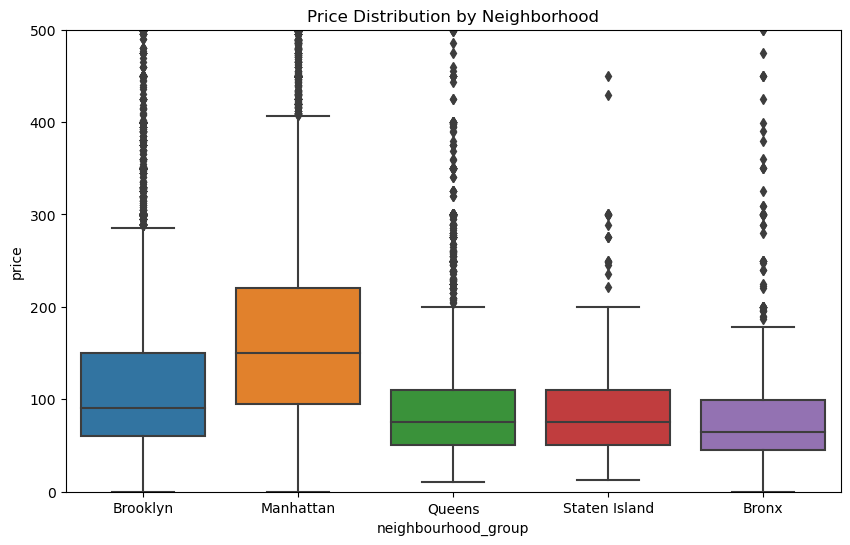

In [5]:
#1. Price Distribution by Neighborhood
plt.figure(figsize=(10, 6))
sns.boxplot(x="neighbourhood_group", y="price", data=air_bnb)
plt.ylim(0, 500)  # Limiting y-axis to remove extreme outliers
plt.title("Price Distribution by Neighborhood")
plt.show()
#📌 Insight: Manhattan has the highest average prices, while the Bronx has the lowest.

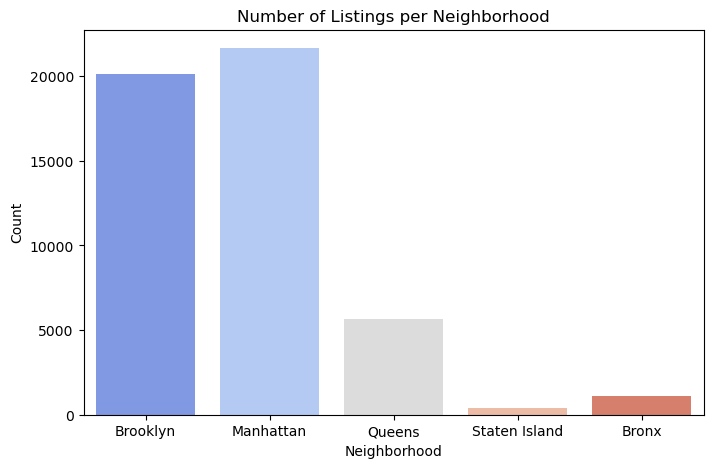

In [18]:
#2. Number of Listings by Neighborhood
plt.figure(figsize=(8, 5))
sns.countplot(x=air_bnb['neighbourhood_group'], palette="coolwarm")
plt.title("Number of Listings per Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Count")
plt.show()
#📌 Insight: Manhattan and Brooklyn have the most

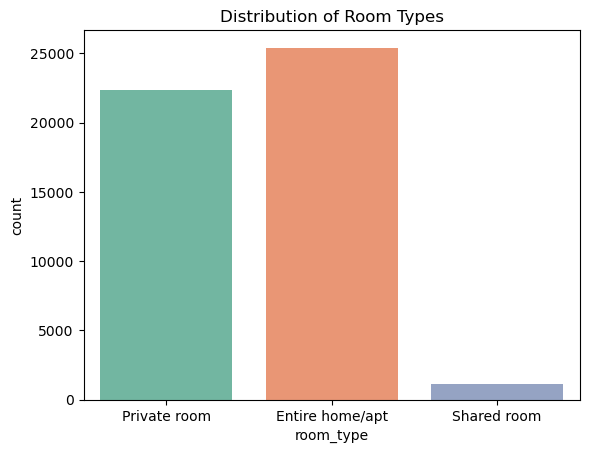

In [17]:
#3. Room Type Distribution


sns.countplot(x=air_bnb['room_type'], palette="Set2")
plt.title("Distribution of Room Types")
plt.show()
#📌 Insight: Entire homes/apartments are the most

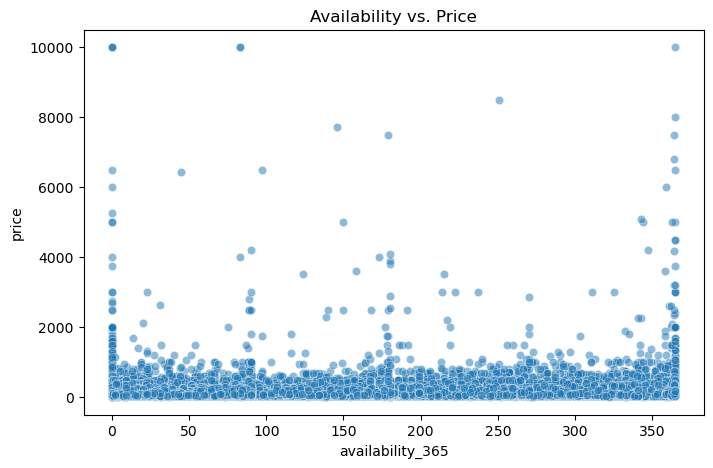

In [15]:
 #4. Availability vs. Price


plt.figure(figsize=(8, 5))
sns.scatterplot(x="availability_365", y="price", data=air_bnb, alpha=0.5)
plt.title("Availability vs. Price")
plt.show()
#📌 Insight: Listings with extreme prices tend to have low availability.



## Further Questions

1. Which host has the most listings?

In [26]:
listing=air_bnb.groupby(['host_name'])['calculated_host_listings_count'].agg('max').sort_values(ascending=False)
print(listing[0:1])

host_name
Sonder (NYC)    327
Name: calculated_host_listings_count, dtype: int64


2. How many listings have completely open availability?

In [248]:
AirB_listings=air_bnb.set_index(['calculated_host_listings_count'])
#AirB_listings
Zero_Ava= (AirB_listings['availability_365'] == 0)
AirB_listings[Zero_Ava]['availability_365'].value_counts()

availability_365
0    17533
Name: count, dtype: int64

3. What room_types have the highest review numbers?

In [66]:
review_numbers=air_bnb.groupby(['room_type'])['number_of_reviews'].max().sort_values(ascending=False)
print(review_numbers[0:1])

room_type
Private room    629
Name: number_of_reviews, dtype: int64


# Final Conclusion

1. Which hosts are the busiest and why?

Michael, David ,Sonder (NYC), John, Alex are the most busy hosts since they are frequently booked by customers as it is proven using value_counts.

2. How many neighborhood groups are available and which shows up the most?

There are five neighborhood groups available , These are Manhattan, Brooklyn, Queens, Bronx, and Staten Island

3. Are private rooms the most popular in manhattan?

  The Entire hom/apt is the most popular in manhattan than private rooms

4. Which hosts are the busiest and based on their reviews?
  According to the review Dona,Jj, Maya, Carol, and Danielle are the top busiest hosts

5. Which neighorhood group has the highest average price?

  Manhattan' has the highest average price with $197 aveage price

6. Which neighbor hood group has the highest total price?
   Brookly, Manhattan and Queens are the three neighbor group with the highest total price    of $10,000

7. Which top 5 hosts have the highest total price?
  Jelena, kathrine, Erin, Matt, and Amy are the five host with highese total price

8. Who currently has no (zero) availability with a review count of 100 or more?
  These hosts are some of the 162 host whove have above 100 review count and has no availablity.
   *MaryEllen  ,Christiana  ,Sol ,Coral  ,Doug ,Kathleen ,Janet  ,Albert ,Stephany  ,Mariluz   
9. What host has the highest total of prices and where are they located?
  Jelena, kathrine, Erin has the highest total price and are located in Manhattan,Queens,     and Brooklyn consecutively  

10. When did Danielle from Queens last receive a review?
   Danielle from Queens received his last review in July 8, 2019.

Further Questions
1. Which host has the most listings 
Sonder has the highest listings
2. How many listings have completely open availability? 
17533 listings have open availabltity 
3. What room_types have the highest review numbers? 
Private room has the highest review numbers.


In [ ]:
3. Challenges & How I Overcame Them
💡 "One challenge was handling missing values in reviews_per_month. I replaced them with 0, assuming that missing values indicate no reviews. Another challenge was dealing with extreme outliers in price, which I addressed by limiting the visualization range and using log transformation for certain analyses."

4. Key Findings & Business Insights
📌 1. Manhattan and Brooklyn dominate the Airbnb market.
📌 2. Private rooms and entire apartments make up most listings.
📌 3. Prices in Manhattan are the highest, while the Bronx is the cheapest.
📌 4. Hosts like Michael, David, and Sonder (NYC) manage the most listings.
📌 5. High-priced listings tend to have lower availability.


1️⃣ What was the goal of your Airbnb data analysis?
🗣 "The goal was to explore trends in pricing, neighborhood demand, and host activity. I used Python for data cleaning, visualization, and extracting business insights."

2️⃣ What insights did you find most interesting?
🗣 "I found that Manhattan dominates the market in both listing count and price. Also, certain hosts manage an exceptionally high number of properties, indicating a commercial Airbnb presence."

3️⃣ How did you handle missing values?
🗣 "For reviews_per_month, I replaced missing values with 0 since no reviews likely mean no activity. For price outliers, I used visualization limits and log transformations."

4️⃣ What visualizations did you use and why?
🗣 "I used bar charts for listing counts, box plots for price distributions, and scatter plots to analyze availability trends. These helped uncover key market insights visually."



